# 1. Import needed libraries

In [2]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

# 2. Preprocessing

## 2.1 Load data

In [3]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [4]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [5]:
tr_df = train_df('/Users/anshikalohan/Downloads/brain-tumor-mri-dataset/Training')

In [6]:
tr_df

,Class Path,Class
0,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
1,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
2,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
3,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
4,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
...,...,...
5595,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
5596,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
5597,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
5598,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma


In [7]:
ts_df = test_df('/Users/anshikalohan/Downloads/brain-tumor-mri-dataset/Testing')

In [8]:
ts_df

,Class Path,Class
0,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
1,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
2,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
3,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
4,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
...,...,...
1595,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
1596,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
1597,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
1598,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma


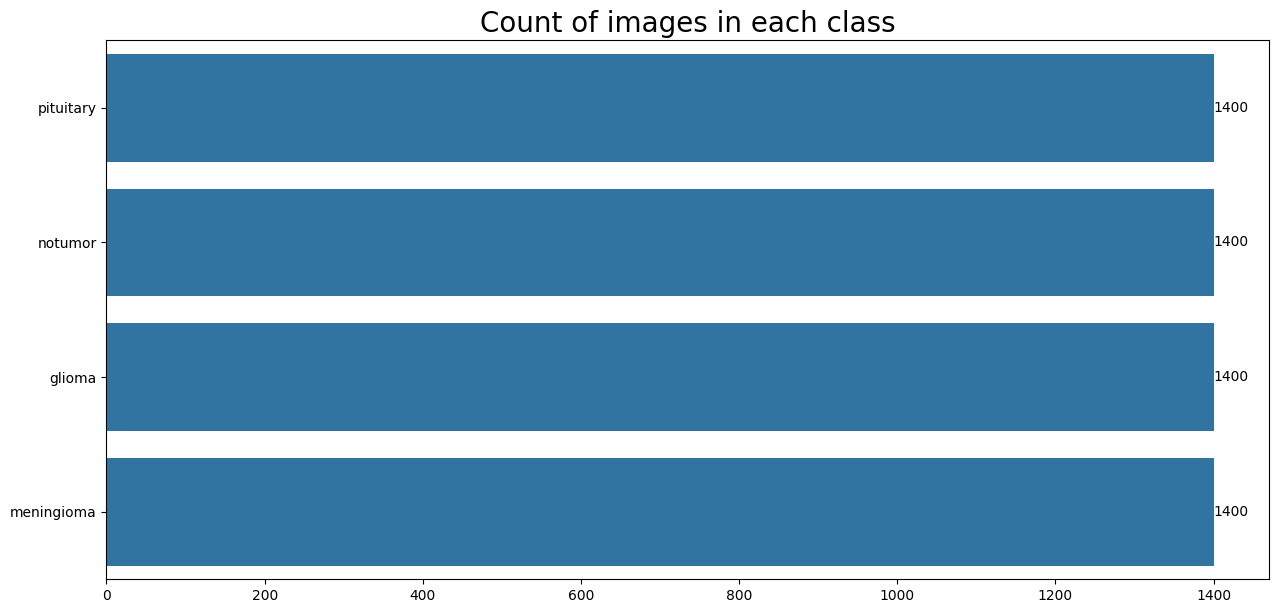

In [9]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

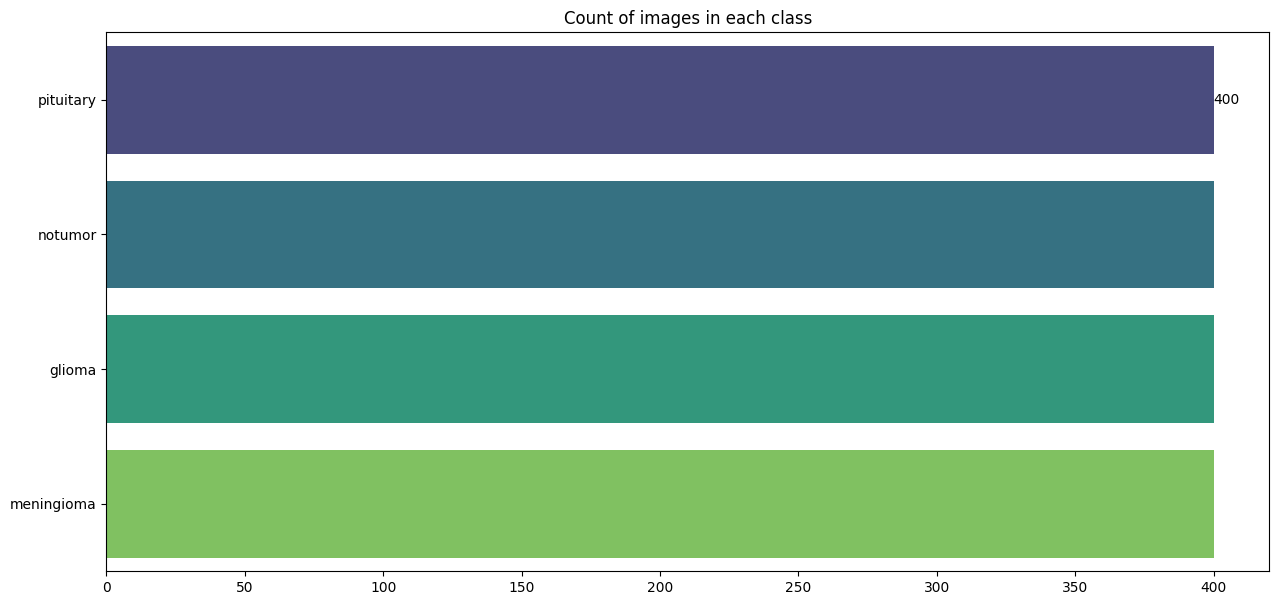

In [10]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

## 2.2 Split data into train, test, valid

In [11]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [12]:
valid_df

,Class Path,Class
198,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
1257,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
1498,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
1519,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma
508,/Users/anshikalohan/Downloads/brain-tumor-mri-...,notumor
...,...,...
881,/Users/anshikalohan/Downloads/brain-tumor-mri-...,glioma
172,/Users/anshikalohan/Downloads/brain-tumor-mri-...,pituitary
792,/Users/anshikalohan/Downloads/brain-tumor-mri-...,notumor
1333,/Users/anshikalohan/Downloads/brain-tumor-mri-...,meningioma


## 2.3 Data preprocessing

In [13]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data

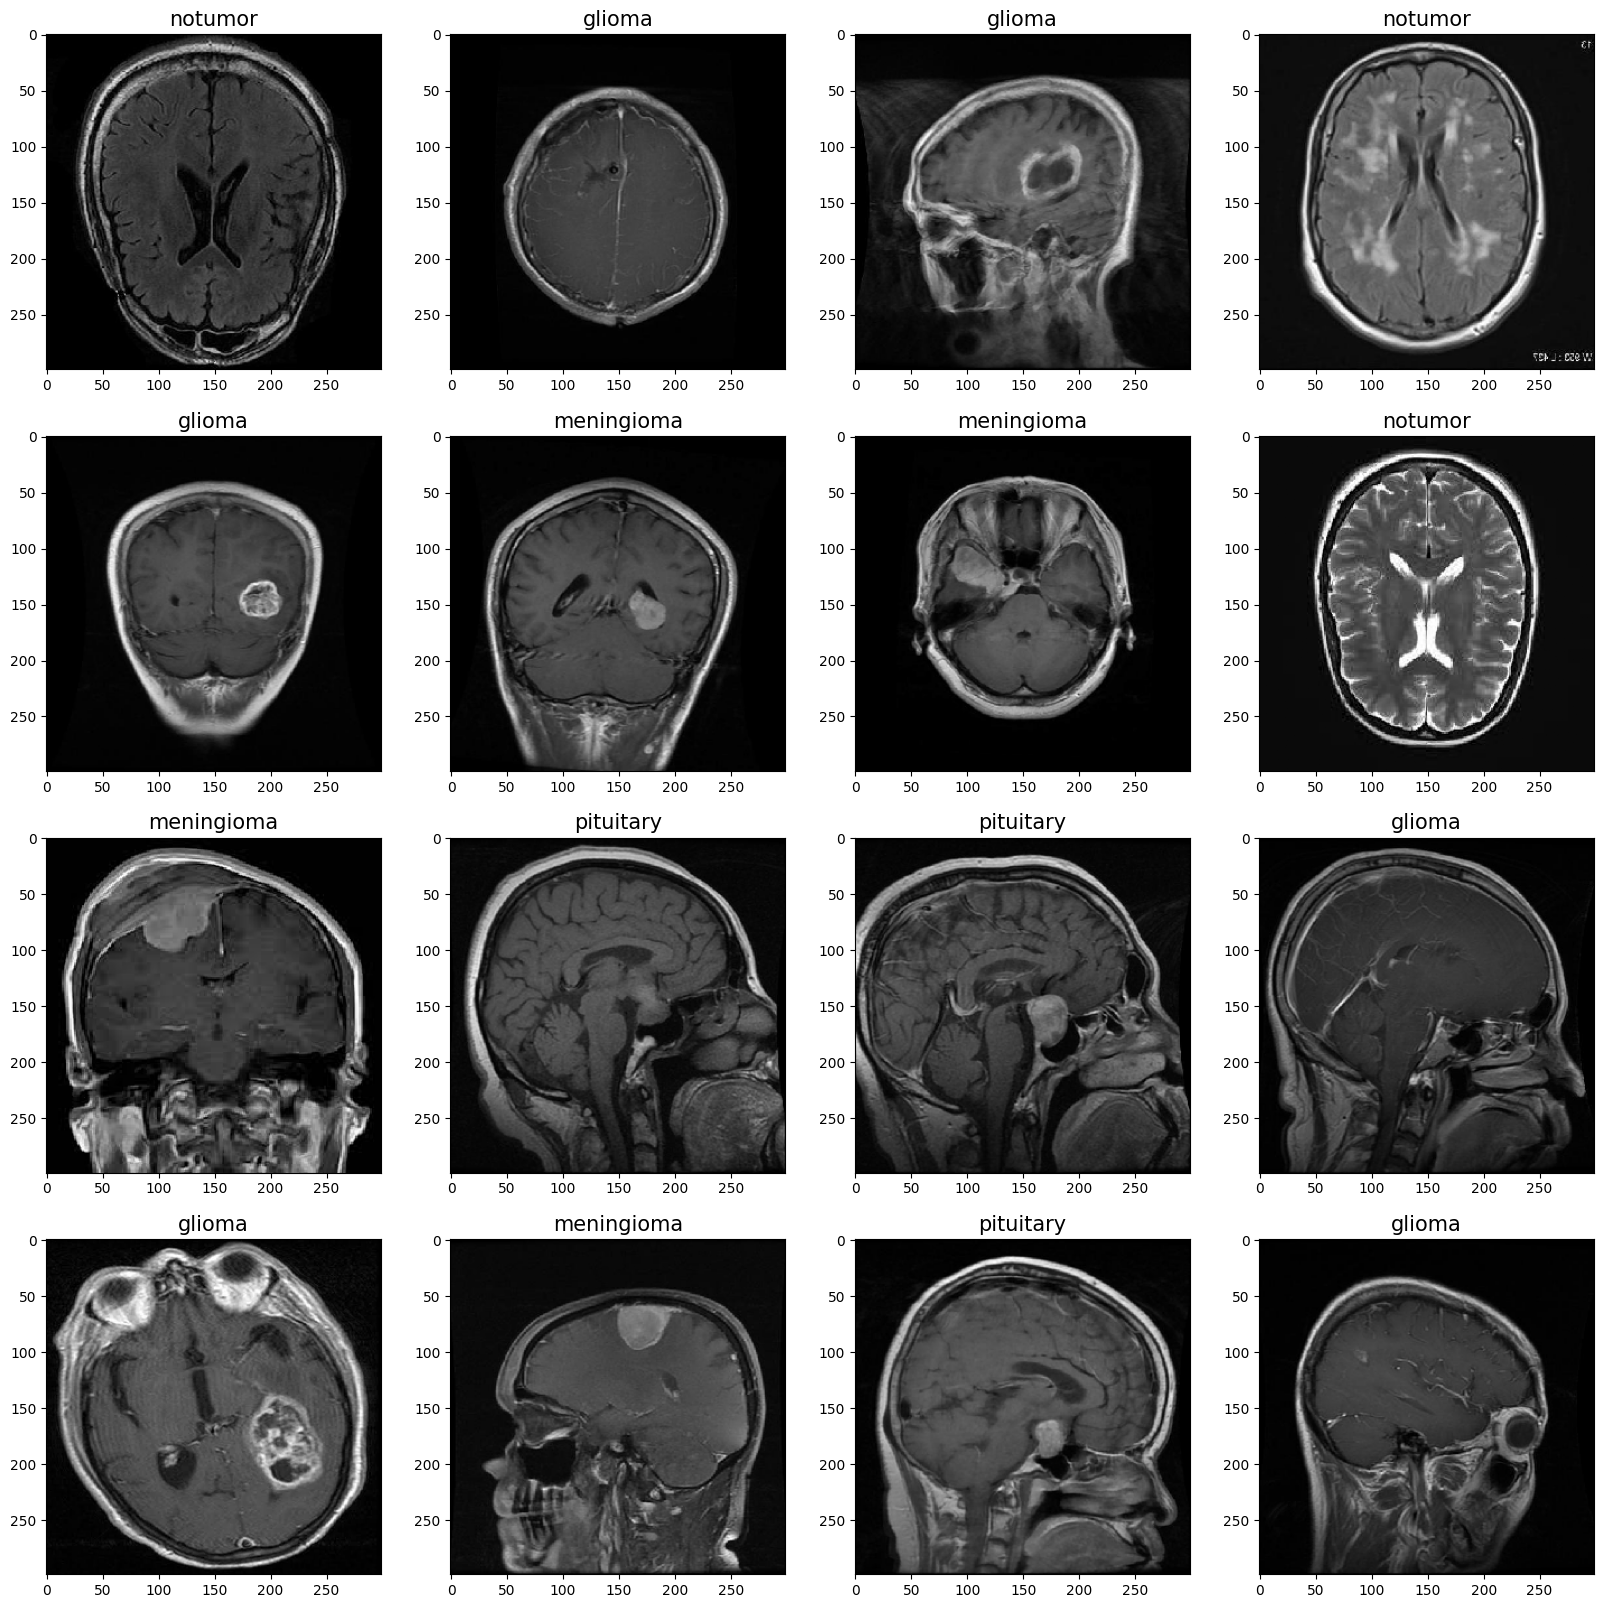

In [14]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

# 3. Building Deep Learning Model

In [17]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')


    
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

# 4. Training

In [21]:
hist = model.fit(tr_gen,
                 epochs=25,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 2454s 14s/step - accuracy: 0.8900 - loss: 0.3294 - precision: 0.9140 - recall: 0.8634 - val_accuracy: 0.9237 - val_loss: 0.2882 - val_precision: 0.9326 - val_recall: 0.9162
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 2464s 14s/step - accuracy: 0.9795 - loss: 0.0641 - precision: 0.9808 - recall: 0.9771 - val_accuracy: 0.8913 - val_loss: 0.4628 - val_precision: 0.8922 - val_recall: 0.8900
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 2777s 16s/step - accuracy: 0.9893 - loss: 0.0334 - precision: 0.9898 - recall: 0.9891 - val_accuracy: 0.9425 - val_loss: 0.3163 - val_precision: 0.9447 - val_recall: 0.9400
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 2364s 14s/step - accuracy: 0.9970 - loss: 0.0092 - precision: 0.9970 - recall: 0.9970 - val_accuracy: 0.9463 - val_loss: 0.3217 - val_precision: 0.9463 - val_recall: 0.9463
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 2459s 14s/step - accuracy: 0.9971 - loss: 0.0104 - precision: 0.9971 - recall: 0.9971 - val_accuracy: 0.9575

In [22]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

## 4.1 Visualize model performance

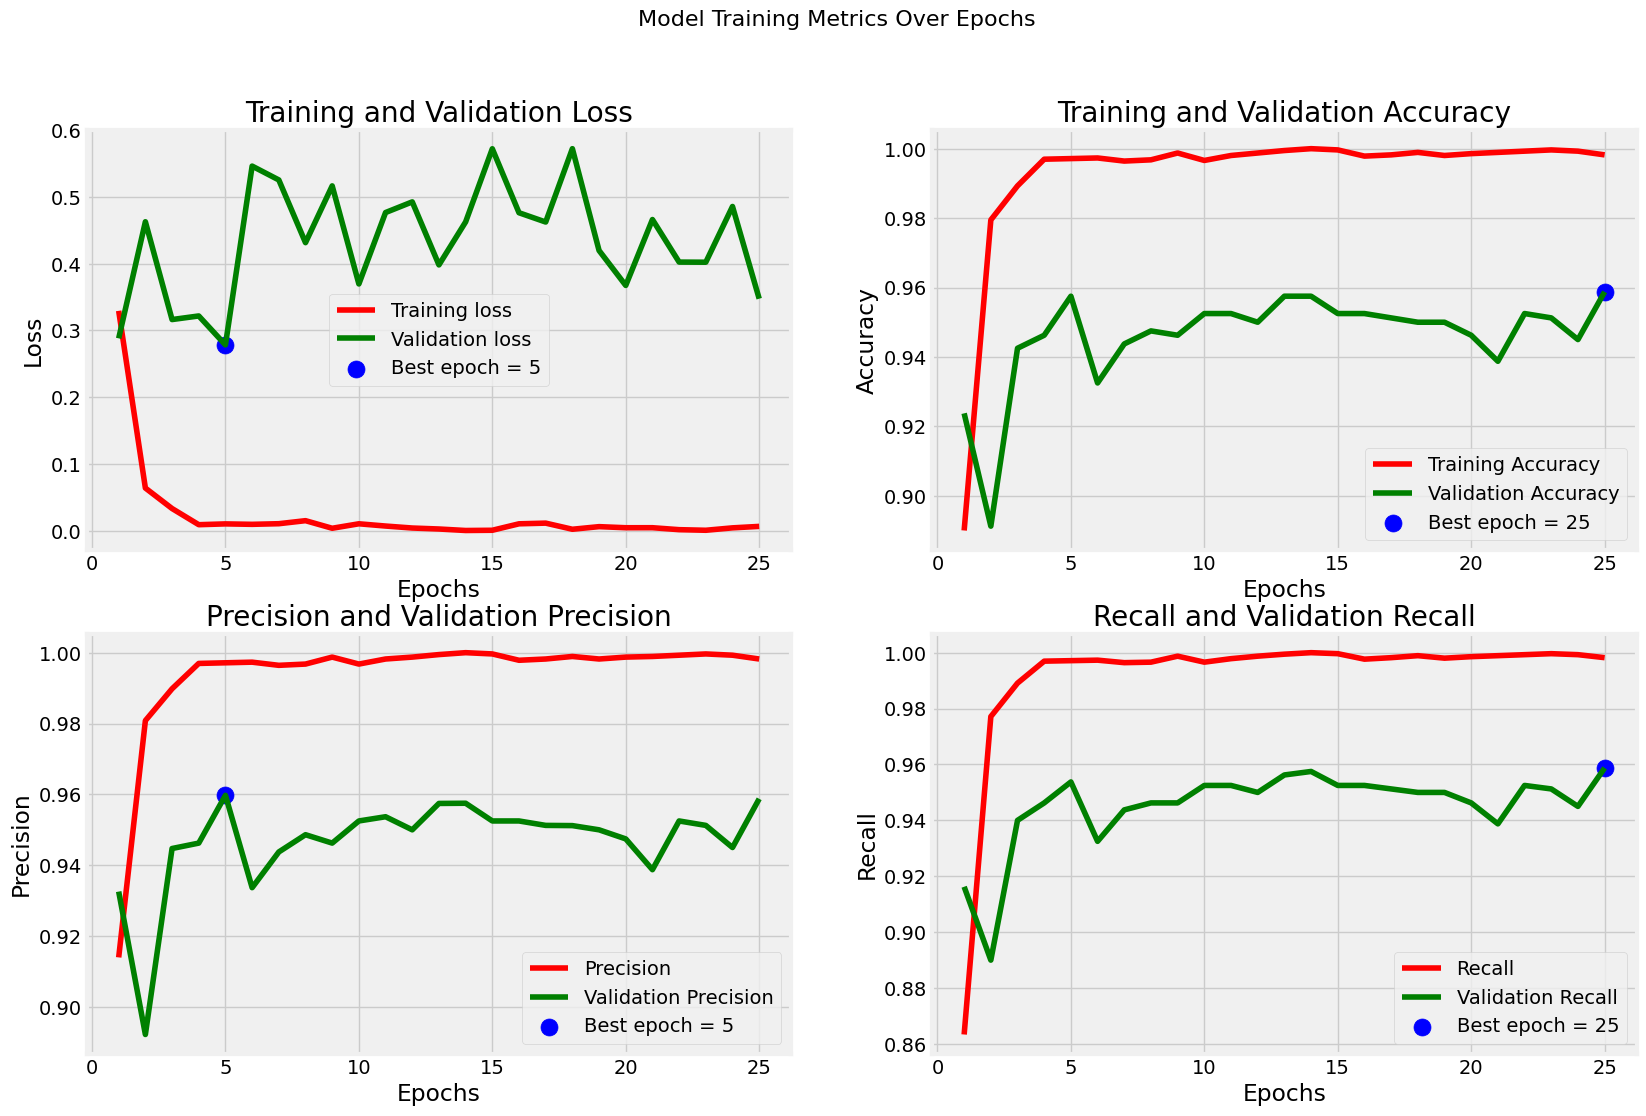

In [23]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

# 5. Evaluation

In [28]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


175/175 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9993 - loss: 0.0040 - precision: 0.9993 - recall: 0.9993
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9588 - loss: 0.3532 - precision: 0.9588 - recall: 0.9588
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9575 - loss: 0.3384 - precision: 0.9575 - recall: 0.9575
Train Loss: 0.0040
Train Accuracy: 99.93%
--------------------
Validation Loss: 0.3532
Validation Accuracy: 95.88%
--------------------
Test Loss: 0.3384
Test Accuracy: 95.75%


In [29]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step


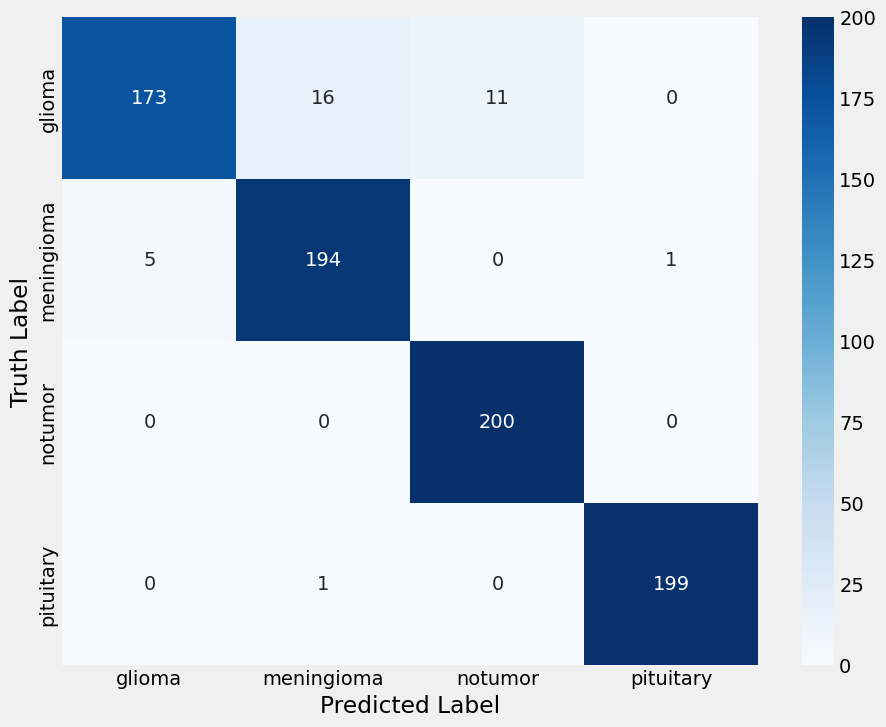

In [30]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [31]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.97      0.86      0.92       200
           1       0.92      0.97      0.94       200
           2       0.95      1.00      0.97       200
           3       0.99      0.99      0.99       200

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



In [32]:
model.save("brain_tumor_classifier.h5")